# Financial Inclusion in Africa

## Dataset Overview

The Financial Inclusion in Africa dataset contains demographic, social, and economic information about individuals across different countries. It is used to understand and predict whether a person has access to a bank account.



## Observations

✔️ The dataset contains both categorical and numerical features

✔️ The target variable is binary (bank account: Yes/No)

✔️ The dataset is imbalanced, with more individuals not having bank accounts

✔️ No missing values are present in the dataset

✔️ Features such as education level, job type, and cellphone access are important indicators of financial inclusion

##  Importing Libraries

The following libraries are used in this project:

- **pandas, numpy** → data manipulation and numerical operations  
- **seaborn, matplotlib** → data visualization  
- **scikit-learn** → preprocessing, model training, and evaluation  
- **XGBoost** → advanced machine learning model for classification  

### Importing libraries

In [6]:
# Data handling

import pandas as pd
import numpy as np

# Visualization

import seaborn as sns
import matplotlib.pyplot as plt

# ML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ✔️ Data Loading

The dataset is loaded from Google Drive into pandas DataFrames.

- **Train dataset**: Contains features and target variable (`bank_account`)
- **Test dataset**: Contains only features (used for prediction)
- **Sample submission**: Shows required output format
- **Variable definitions**: Provides description of each feature

In [8]:
# Load files into a pandas dataframe
path = "/content/drive/MyDrive/Colab Notebooks/Data/"

train = pd.read_csv(path+ 'Train.csv')
test = pd.read_csv(path+ 'Test.csv')
ss = pd.read_csv(path+ 'SampleSubmission.csv')
variables = pd.read_csv(path+ 'VariableDefinitions.csv')

In [9]:
ss.to_csv(path+"new_ss.csv", index = False)

In [10]:
print("Test shape:", test.shape)
print("SampleSubmission shape:", ss.shape)

Test shape: (10086, 12)
SampleSubmission shape: (33610, 2)


In [11]:
# Let’s observe the shape of our datasets.
print('train data shape :', train.shape)
print('test data shape :', test.shape)

train data shape : (23524, 13)
test data shape : (10086, 12)


# Statistical EDA

## Dataset Information

The `info()` function provides an overview of the dataset, including:

- Total number of entries  
- Data types of each feature  
- Presence of missing values  

In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


- The dataset contains both numerical and categorical features  
- No missing values are present in any column  
- Most features are categorical (object type), requiring encoding before modeling  

## Missing Values Check

This step checks for missing values in each column of the dataset.

In [13]:
train.isnull().sum()

,0
country,0
year,0
uniqueid,0
bank_account,0
location_type,0
cellphone_access,0
household_size,0
age_of_respondent,0
gender_of_respondent,0
relationship_with_head,0


- The dataset is mostly clean with no missing values across all original features  
- A single missing value is observed in the engineered feature `household_group`  
- Since this feature was created using binning, the missing value likely comes from values falling outside the defined bin range  

This indicates that the original dataset is clean, and only minor preprocessing is required.

##  Statistical Summary

The `describe()` function provides summary statistics for numerical features, including:

- Mean (average)
- Standard deviation
- Minimum and maximum values
- Quartiles (25%, 50%, 75%)

In [14]:
train.describe()

,year,household_size,age_of_respondent
count,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220
std,0.847371,2.227613,16.520569
min,2016.000000,1.000000,16.000000
25%,2016.000000,2.000000,26.000000
50%,2017.000000,3.000000,35.000000
75%,2018.000000,5.000000,49.000000
max,2018.000000,21.000000,100.000000


- Numerical features such as age and household size show a reasonable range of values  
- The difference between mean and median suggests slight skewness in some features  
- The presence of high maximum values compared to quartiles indicates potential outliers  

These observations suggest that scaling is required, and outliers should be considered during modeling.

In [15]:
# inspect train data
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


## Numerical Feature Distribution

This section visualizes the distribution of numerical features using histograms and KDE plots.

It helps to understand:

- Data distribution shape (normal, skewed, etc.)
- Presence of outliers
- Feature variability

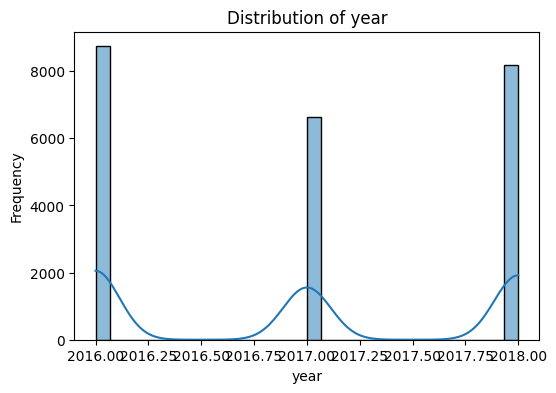

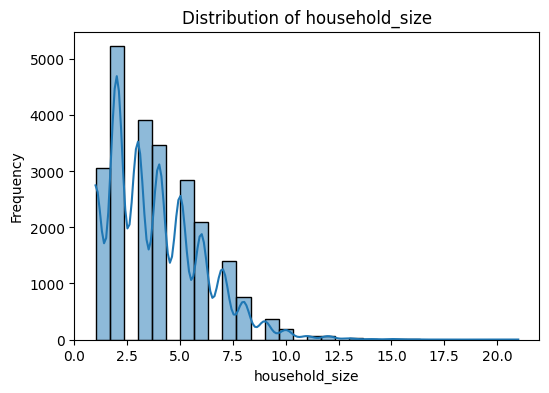

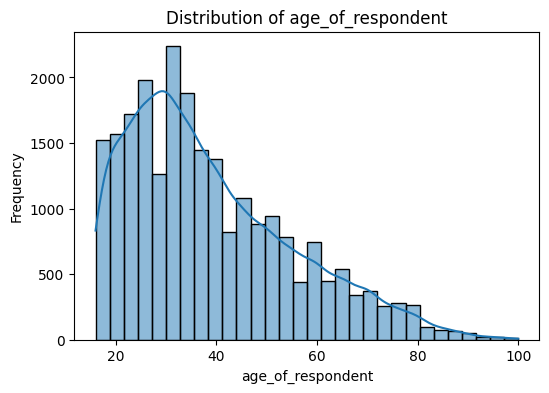

In [16]:
# Select numerical columns
num_cols = train.select_dtypes(include=["int64", "float64"]).columns

# Distribution plots for numerical features
for col in num_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(train[col], bins=30, kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

- Some numerical features show skewed distributions  
- Certain features are concentrated in specific ranges  
- Outliers may exist in age and household size  
- Most distributions are not perfectly normal  

This indicates that scaling and possibly transformation will be important during preprocessing.

## Outlier Detection (Boxplots)

Boxplots are used to detect:

- Outliers  
- Data spread  
- Median position  
- Skewness indication  

This helps understand whether data preprocessing (like scaling or outlier handling) is required.

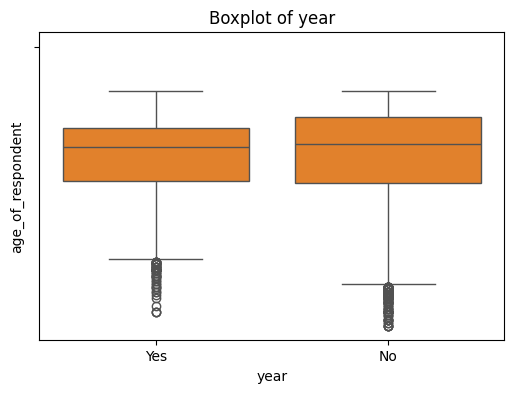

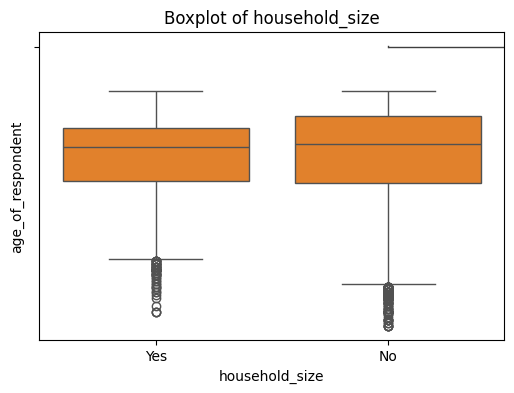

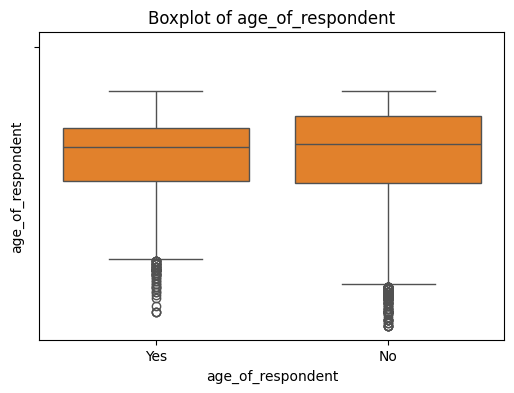

In [17]:
# Boxplots for Numerical Features

for col in num_cols:
    plt.figure(figsize=(6,4))

    sns.boxplot(x=train[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    sns.boxplot(x="bank_account", y="age_of_respondent", data=train)

    plt.show()

- Several numerical features contain outliers  
- Age and household size show noticeable extreme values  
- Most features are right-skewed (long tail on the right side)  

This indicates that scaling is necessary, and models sensitive to outliers may be affected.

## Skewness Analysis

Skewness measures the asymmetry of the data distribution:

- Positive skew → long tail on the right  
- Negative skew → long tail on the left  
- Near 0 → approximately symmetric distribution  

In [18]:
train[num_cols].skew()

,0
year,0.045664
household_size,0.988200
age_of_respondent,0.841686


- Several numerical features show positive skewness  
- This indicates that most values are concentrated on the lower range with few large values  
- Highly skewed features may affect model performance, especially for linear models  

Therefore, scaling and possible transformation may be required during preprocessing.

## Skewness Visualization

This plot shows the skewness level of each numerical feature.

- Values > 0 → right skewed distribution  
- Values < 0 → left skewed distribution  
- Values near 0 → approximately normal distribution  

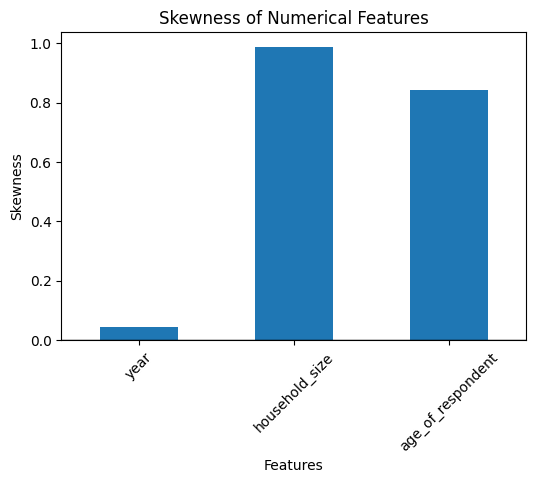

In [19]:
# Skewness Visualization of Numerical Features

skew_values = train[num_cols].skew()

skew_values.plot(kind="bar", figsize=(6,4))

plt.title("Skewness of Numerical Features")
plt.ylabel("Skewness")
plt.xlabel("Features")

plt.xticks(rotation=45)
plt.axhline(0, color="black", linewidth=1)

plt.show()

- Most numerical features show positive skewness  
- This indicates the presence of long right tails in the data  
- Some features deviate significantly from normal distribution  

This suggests that scaling is necessary, and transformations may improve model performance.

Due to the presence of skewed distributions in numerical features, MinMaxScaler is applied during preprocessing to normalize feature ranges and improve model stability.

## Categorical Feature Analysis

This section visualizes the most frequent categories (Top 10) in each categorical feature.

It helps to understand:

- Dominant categories in the dataset  
- Class imbalance within features  
- Distribution patterns across categorical variables  

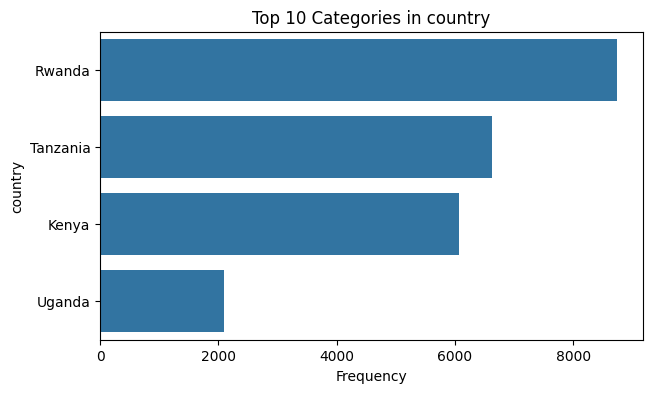

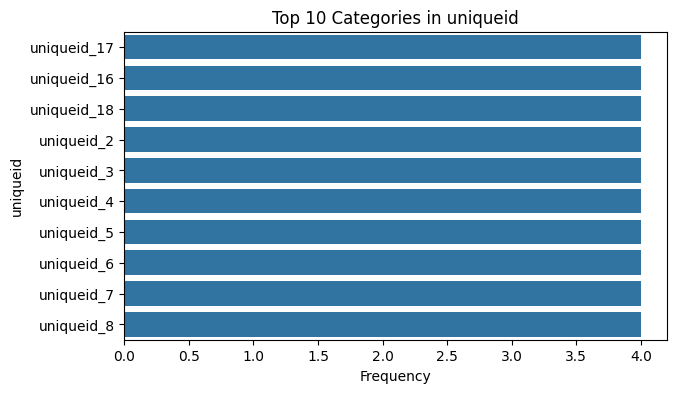

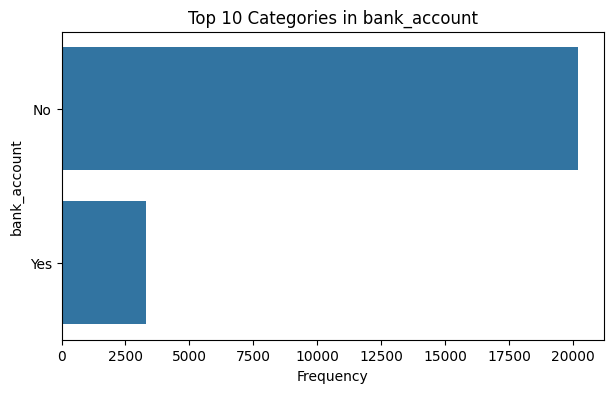

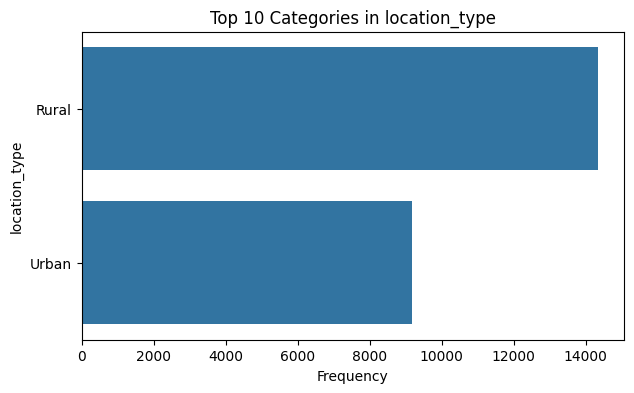

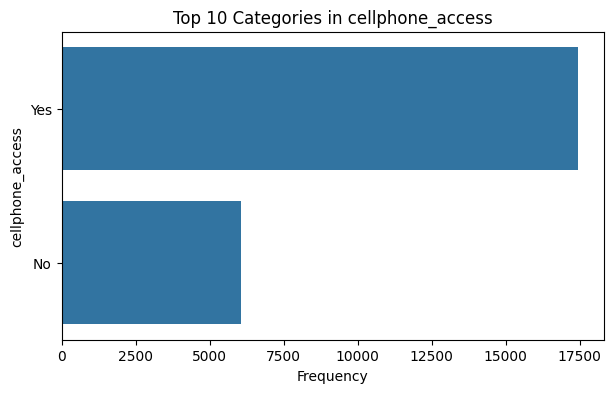

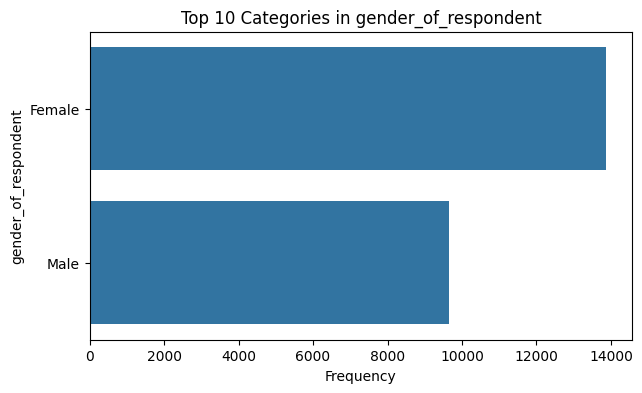

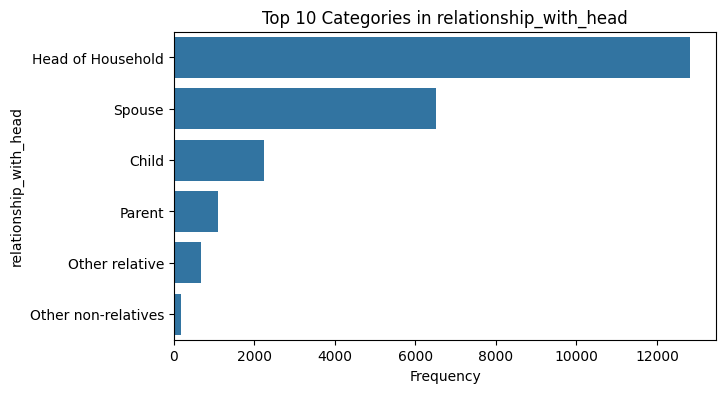

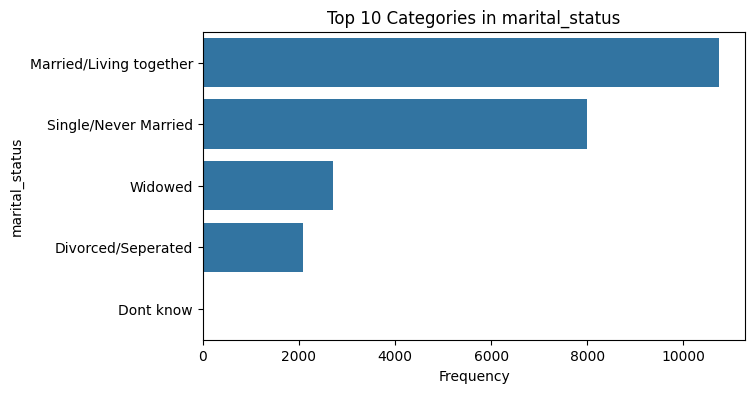

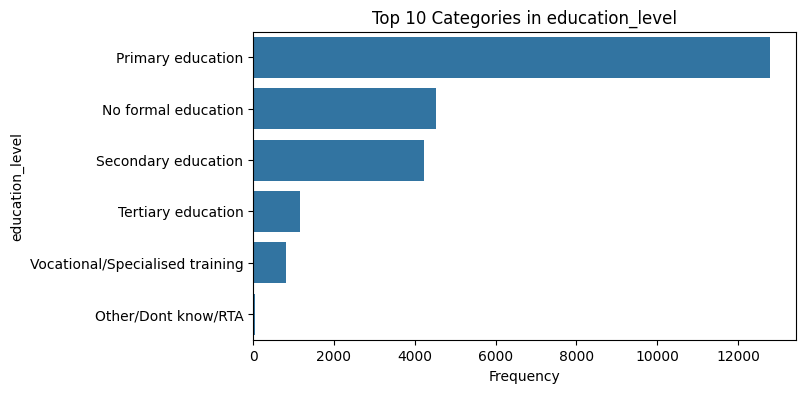

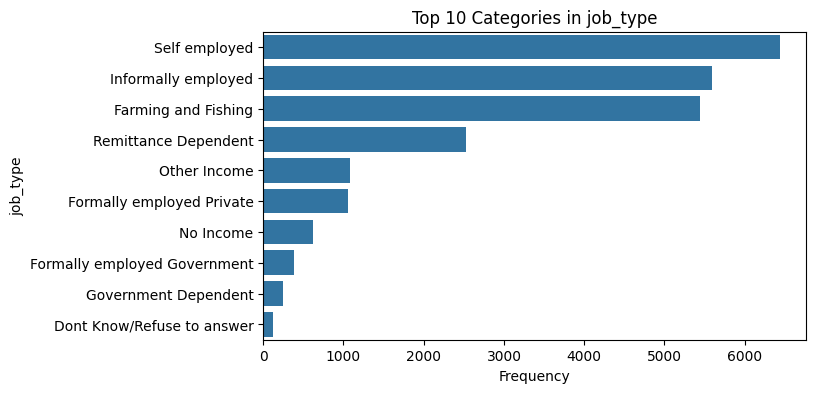

In [20]:
# Categorical Columns
cat_cols = train.select_dtypes(include="object").columns

# Top 10 category distribution for each categorical feature
for col in cat_cols:
    plt.figure(figsize=(7,4))

    top10 = train[col].value_counts().nlargest(10)

    sns.barplot(x=top10.values, y=top10.index)

    plt.title(f"Top 10 Categories in {col}")
    plt.xlabel("Frequency")
    plt.ylabel(col)

    plt.show()

- Several categorical features are dominated by a few major categories  
- Some features show strong imbalance between categories  
- This may influence model bias toward dominant groups  

Proper encoding (One-Hot Encoding) is required since categories have no ordinal relationship.


Due to the presence of multiple non-ordinal categorical variables, One-Hot Encoding is applied to convert categorical features into numerical format without introducing artificial ranking.

## Target Variable Analysis

This section analyzes the distribution of the target variable (`bank_account`), which is a binary classification problem:

- 0 → No bank account  
- 1 → Has bank account  

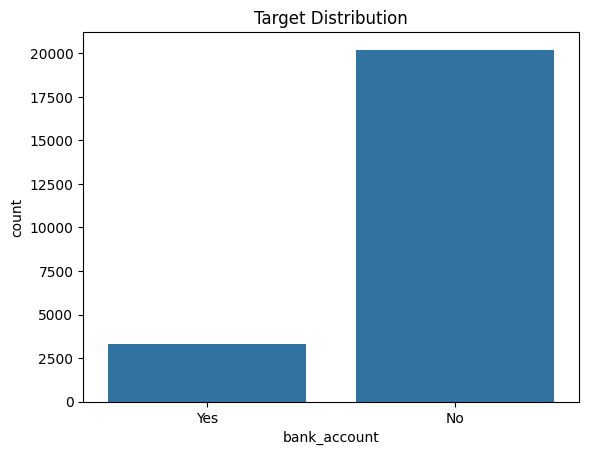

,proportion
bank_account,
No,0.859208
Yes,0.140792


In [21]:
# Target Distribution

sns.countplot(x="bank_account", data=train)
plt.title("Target Distribution")
plt.show()

train["bank_account"].value_counts(normalize=True)

- The dataset is imbalanced, with a higher number of people without bank accounts  
- This imbalance can bias the model toward the majority class  
- Accuracy alone may not be a reliable metric  

Therefore, additional evaluation methods and imbalance handling techniques are required.


Due to class imbalance in the target variable, the model uses:

- `scale_pos_weight` in XGBoost  
- Confusion matrix for evaluation instead of only accuracy  

## Relationship Analysis: Education vs Bank Account

This plot shows how education level affects the likelihood of owning a bank account.

It compares:
- Education categories
- Bank account status (Yes/No)

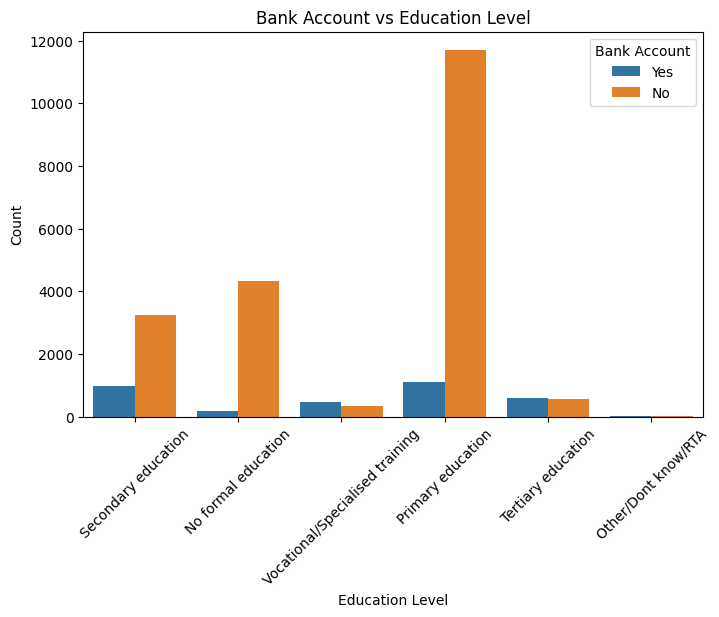

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x="education_level", hue="bank_account", data=train)

plt.xticks(rotation=45)
plt.title("Bank Account vs Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.legend(title="Bank Account")

plt.show()

- Higher education levels are associated with a higher likelihood of owning a bank account  
- Individuals with lower education levels are more likely to not have a bank account  
- Education appears to be a strong predictor of financial inclusion  

This suggests that education level is an important feature for model training.


Due to the strong relationship between education level and bank account ownership, this feature is retained and encoded using One-Hot Encoding to preserve categorical structure.

## Correlation Analysis

This heatmap shows the correlation between numerical features.

- Values close to +1 → strong positive correlation  
- Values close to -1 → strong negative correlation  
- Values near 0 → weak or no relationship  

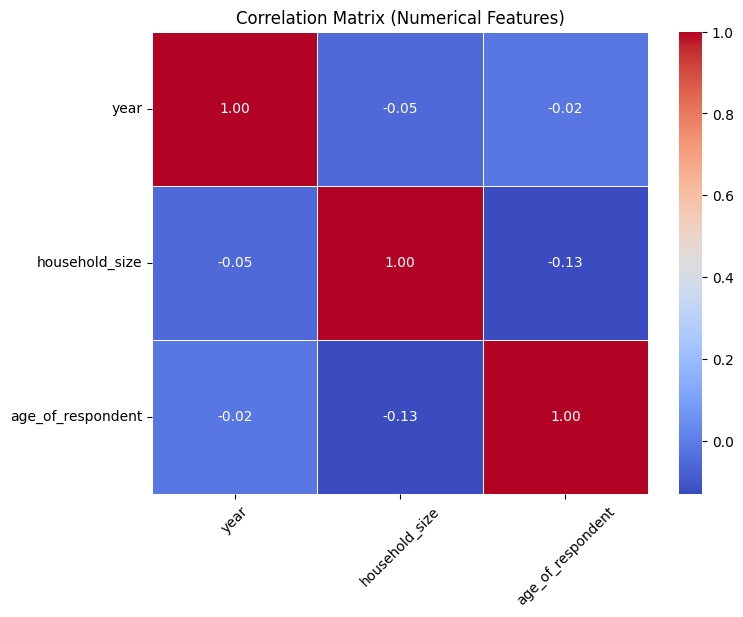

In [23]:
plt.figure(figsize=(8,6))

corr_matrix = train[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

- Most numerical features show weak correlation with each other  
- No strong multicollinearity is observed  
- Features appear relatively independent  

This is beneficial for machine learning models, as highly correlated features can reduce model performance.

Since no strong multicollinearity is detected, all numerical features are retained for model training without feature removal.

## Unique Value Analysis

This step shows the number of unique values in each feature.

It helps to:

- Identify categorical vs numerical behavior
- Detect high-cardinality features
- Understand feature diversity

In [24]:
train.nunique().sort_values(ascending=False)

,0
uniqueid,8735
age_of_respondent,85
household_size,20
job_type,10
relationship_with_head,6
education_level,6
marital_status,5
country,4
year,3
location_type,2


- Features like `uniqueid` have very high cardinality and are not useful for prediction  
- Categorical features have moderate number of unique values  
- Numerical features have low unique counts as expected  

This helps in deciding which features to drop or encode.

- `uniqueid` is dropped as it does not contribute to prediction  
- Categorical features are encoded using One-Hot Encoding  
- High-cardinality columns are handled carefully to avoid dimensional explosion  

## Categorical Feature Distribution

This section shows the percentage distribution of each category within categorical features.

It helps to understand:

- Dominant categories
- Rare categories
- Imbalance within categorical variables

In [25]:
for col in cat_cols:
    print(f"\n{col} distribution (%):")
    print(train[col].value_counts(normalize=True) * 100)


country distribution (%):
country
Rwanda      37.132290
Tanzania    28.141473
Kenya       25.794933
Uganda       8.931304
Name: proportion, dtype: float64

uniqueid distribution (%):
uniqueid
uniqueid_17      0.017004
uniqueid_16      0.017004
uniqueid_18      0.017004
uniqueid_2       0.017004
uniqueid_3       0.017004
                   ...   
uniqueid_7303    0.004251
uniqueid_7302    0.004251
uniqueid_7301    0.004251
uniqueid_7300    0.004251
uniqueid_7308    0.004251
Name: proportion, Length: 8735, dtype: float64

bank_account distribution (%):
bank_account
No     85.920762
Yes    14.079238
Name: proportion, dtype: float64

location_type distribution (%):
location_type
Rural    60.971774
Urban    39.028226
Name: proportion, dtype: float64

cellphone_access distribution (%):
cellphone_access
Yes    74.196565
No     25.803435
Name: proportion, dtype: float64

gender_of_respondent distribution (%):
gender_of_respondent
Female    58.990818
Male      41.009182
Name: proportion, dtype

- Several categorical features are dominated by one or two major categories  
- Some features show strong imbalance across categories  
- Rare categories may have limited predictive power  

This affects encoding strategy and model behavior.

- One-Hot Encoding is applied to preserve category independence  
- Rare categories are kept but monitored for low impact  
- No categorical feature is dropped at this stage  

## Relationship: Education Level vs Bank Account

This analysis shows the percentage of people with and without bank accounts within each education level.

Normalization by index ensures each row sums to 100%, making comparisons easier.

In [26]:
pd.crosstab(
    train["education_level"],
    train["bank_account"],
    normalize="index"
) * 100

bank_account,No,Yes
education_level,,
No formal education,96.101883,3.898117
Other/Dont know/RTA,68.571429,31.428571
Primary education,91.454929,8.545071
Secondary education,76.722709,23.277291
Tertiary education,48.919620,51.080380
Vocational/Specialised training,42.963885,57.036115


- Higher education levels tend to have a higher percentage of bank account ownership  
- Lower education levels are associated with lower financial inclusion  
- Education is a strong indicator of financial access  

This confirms education as an important predictive feature.

Due to the strong relationship between education level and bank account ownership, this feature is retained and encoded using One-Hot Encoding to preserve category independence.

## Target Class Distribution

This shows the percentage distribution of the target variable (`bank_account`):

- 0 → No bank account  
- 1 → Has bank account  

In [27]:
train["bank_account"].value_counts(normalize=True) * 100

,proportion
bank_account,
No,85.920762
Yes,14.079238


- The dataset is imbalanced  
- Majority of individuals do not have bank accounts  
- Minority class (bank account holders) is underrepresented  

This imbalance can bias the model toward predicting the majority class.

To handle class imbalance:

- `scale_pos_weight` is used in XGBoost  
- Confusion matrix is used for evaluation  
- Error rate is preferred over accuracy  

## Relationship: Age vs Bank Account

This boxplot compares the age distribution of individuals with and without bank accounts.

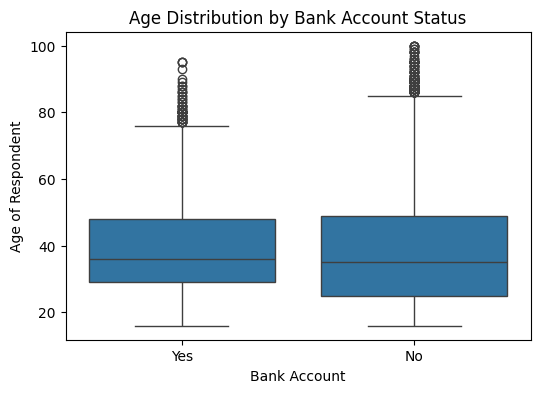

In [28]:
plt.figure(figsize=(6,4))

sns.boxplot(x="bank_account", y="age_of_respondent", data=train)

plt.title("Age Distribution by Bank Account Status")
plt.xlabel("Bank Account")
plt.ylabel("Age of Respondent")

plt.show()

- Individuals with bank accounts tend to be older on average  
- Younger respondents are more likely to not have a bank account  
- Age appears to influence financial inclusion behavior  

This suggests age is an important predictive feature.

Since age shows a meaningful relationship with the target variable, it is retained as a key numerical feature for model training and scaled during preprocessing.

## Relationship: Household Size vs Bank Account

This boxplot compares household size between individuals with and without bank accounts.

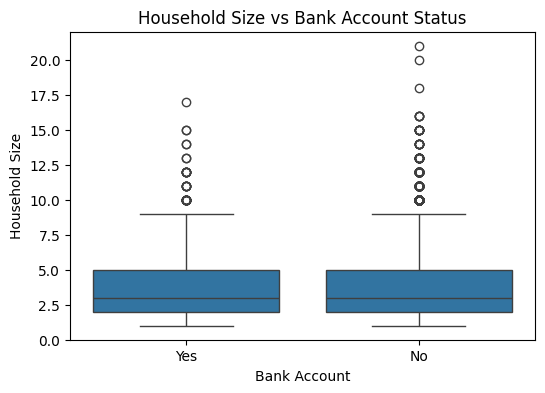

In [29]:
plt.figure(figsize=(6,4))

sns.boxplot(x="bank_account", y="household_size", data=train)

plt.title("Household Size vs Bank Account Status")
plt.xlabel("Bank Account")
plt.ylabel("Household Size")

plt.show()

- Individuals with smaller household sizes are slightly more likely to have a bank account  
- Larger households tend to have lower financial inclusion  
- The relationship is weaker compared to features like education or age  

This suggests household size has moderate predictive power.

Household size is retained as a numerical feature, but its predictive strength is lower compared to other features. It is still included in model training and scaled during preprocessing.

## Temporal Analysis: Year vs Bank Account

This plot shows how bank account ownership is distributed across different years in the dataset.

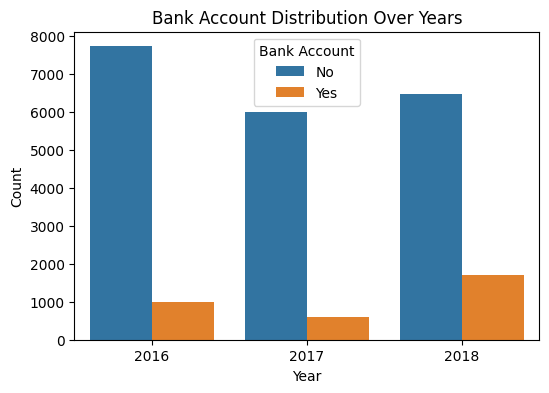

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x="year", hue="bank_account", data=train)

plt.title("Bank Account Distribution Over Years")
plt.xlabel("Year")
plt.ylabel("Count")

plt.legend(title="Bank Account")

plt.show()

- The distribution of bank account ownership is relatively stable across years  
- No strong temporal trend is observed in financial inclusion  
- Class imbalance persists in every year  

This indicates that year alone is not a strong predictive feature.

Since the "year" feature does not show strong variation in the target distribution, it has limited predictive power but is still retained for completeness in the model.

## Feature Comparison by Target Class

This analysis compares the mean values of numerical features between:

- Individuals with a bank account  
- Individuals without a bank account  

In [31]:
train.groupby("bank_account")[num_cols].mean()

,year,household_size,age_of_respondent
bank_account,,,
No,2016.937413,3.823026,38.675292
Yes,2017.211051,3.641606,39.598128


- Age is higher on average for individuals with bank accounts  
- Household size tends to be smaller for bank account holders  
- Numerical features show noticeable differences between classes  

This confirms that numerical features carry predictive signal for the model.

Since clear differences exist between the two classes, numerical features are considered important and are retained for model training with proper scaling applied.

## Class Imbalance Analysis

This step calculates the percentage distribution of the target variable (`bank_account`).

In [32]:
imbalance = train["bank_account"].value_counts(normalize=True) * 100
imbalance

,proportion
bank_account,
No,85.920762
Yes,14.079238


- The dataset is highly imbalanced  
- Majority class: No bank account (~86%)  
- Minority class: Has bank account (~14%)  

This imbalance can bias the model toward predicting the majority class.


To handle class imbalance:

- `scale_pos_weight` is used in XGBoost  
- Confusion matrix is used for evaluation  
- Error rate is preferred over accuracy  

## Target Class Imbalance Visualization

This bar plot visualizes the percentage distribution of the target variable (`bank_account`).

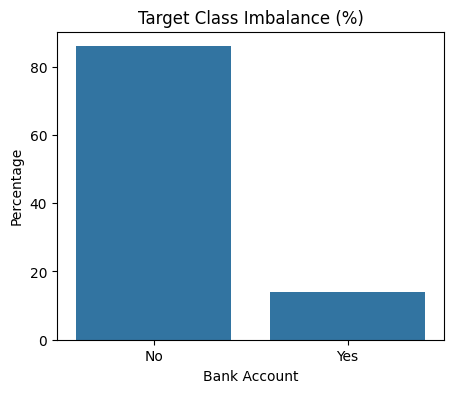

In [33]:
plt.figure(figsize=(5,4))

sns.barplot(x=imbalance.index, y=imbalance.values)

plt.title("Target Class Imbalance (%)")
plt.xlabel("Bank Account")
plt.ylabel("Percentage")

plt.show()

- The dataset is heavily imbalanced  
- Majority class dominates the dataset  
- Minority class is significantly underrepresented  

This imbalance can negatively affect model learning if not handled properly.

To address class imbalance:

- `scale_pos_weight` is used in XGBoost  
- Evaluation focuses on confusion matrix instead of accuracy  
- Error rate is considered a key metric  

## Train vs Test Distribution Check

This analysis compares the distribution of numerical features in the training and test datasets.

It helps to detect:
- Distribution shifts between datasets  
- Data leakage risks  
- Model generalization issues  

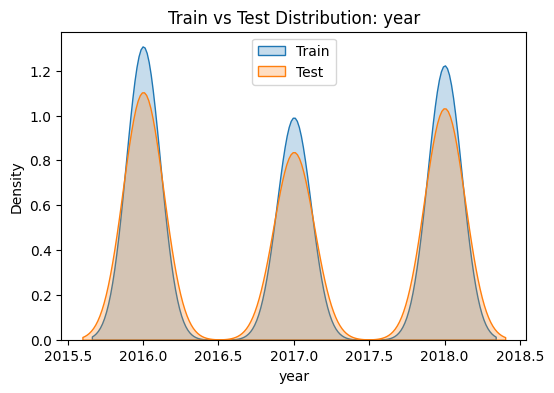

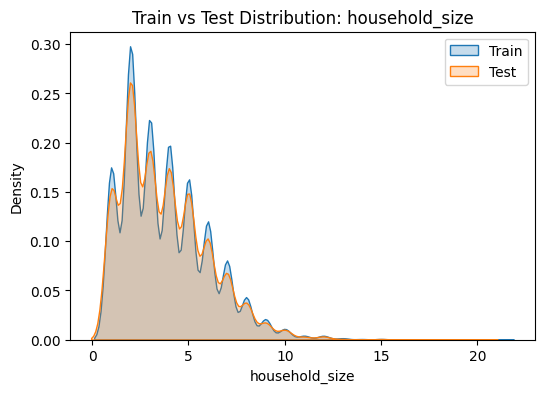

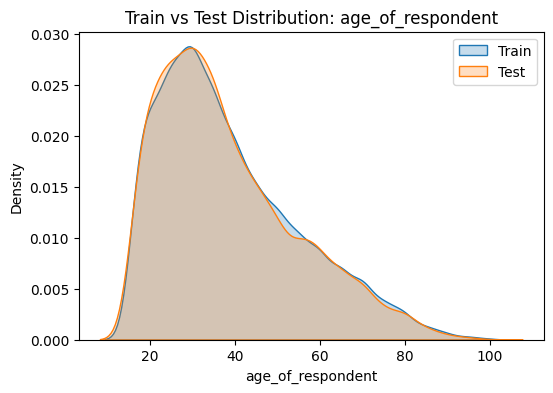

In [34]:
# Select numerical columns
num_cols = train.select_dtypes(include=["int64", "float64"]).columns

# Ensure only common columns exist in both train and test
common_cols = train.columns.intersection(test.columns)
num_cols = [col for col in num_cols if col in common_cols]

# Train vs Test distribution comparison
for col in num_cols:
    plt.figure(figsize=(6,4))

    sns.kdeplot(train[col], label="Train", fill=True)
    sns.kdeplot(test[col], label="Test", fill=True)

    plt.title(f"Train vs Test Distribution: {col}")
    plt.legend()

    plt.show()

- Most features show similar distributions in train and test sets  
- No significant distribution shift is observed  
- This indicates that the model is likely to generalize well on unseen data  

However, minor differences may still exist and should be monitored.

Since no major distribution shift is detected between train and test datasets, the same preprocessing pipeline can be safely applied to both datasets.

## Median Comparison by Target Class

This analysis compares the median values of numerical features between:

- Individuals with a bank account  
- Individuals without a bank account  

Median is used because it is less sensitive to outliers than the mean.

In [35]:
train.groupby("bank_account")[num_cols].median()

,year,household_size,age_of_respondent
bank_account,,,
No,2017.0,3.0,35.0
Yes,2018.0,3.0,36.0


- Median age is higher for individuals with bank accounts  
- Household size tends to be lower for bank account holders  
- Median values confirm trends seen in mean comparison  

This indicates that the relationship between numerical features and target is consistent and not heavily influenced by outliers.

Since median and mean trends are consistent, numerical features are considered reliable predictors and are retained for model training with scaling applied.

## Variance Analysis

Variance measures how much the values of a feature are spread out from the mean.

- High variance → wide spread of values  
- Low variance → values are more concentrated  

In [36]:
train[num_cols].var().sort_values(ascending=False)

,0
age_of_respondent,272.929198
household_size,4.962259
year,0.718037


- Age shows the highest variability, meaning respondents come from a wide age range  
- Household size has limited variation compared to age  
- Year has very low variance, meaning it contributes little variation to the dataset  

Features with higher variance may carry more information for prediction.

- `age_of_respondent` is an important feature due to high variability  
- `household_size` is moderately important  
- `year` has low predictive power but is retained for consistency  

All features are scaled to ensure fair contribution during model training.

## Age Group vs Bank Account

This analysis groups respondents into age categories to better understand how age influences financial inclusion.

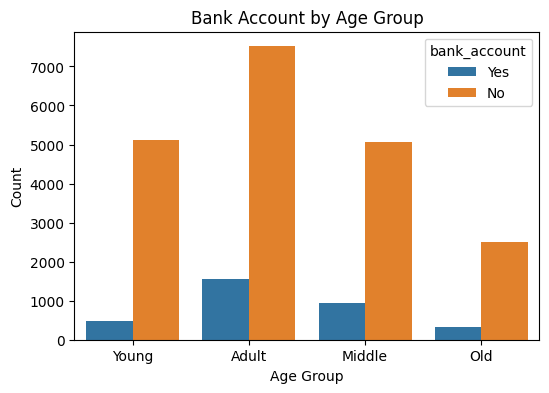

In [37]:
# Create age groups
train["age_group"] = pd.cut(
    train["age_of_respondent"],
    bins=[0, 25, 40, 60, 100],
    labels=["Young", "Adult", "Middle", "Old"]
)

# Visualization
plt.figure(figsize=(6,4))

sns.countplot(x="age_group", hue="bank_account", data=train)

plt.title("Bank Account by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

- Younger individuals have the lowest bank account ownership  
- Middle and older age groups are more likely to have bank accounts  
- Financial inclusion increases with age  

This suggests that age is a strong predictor of financial behavior.

A new feature (`age_group`) is created to capture non-linear relationships between age and financial inclusion. This feature is included in the model using One-Hot Encoding.

## Household Size vs Bank Account

This analysis groups household sizes into categories to better understand their relationship with financial inclusion.

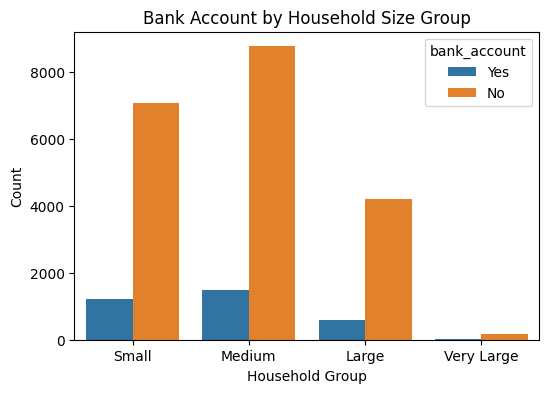

In [38]:
# Create household size groups
train["household_group"] = pd.cut(
    train["household_size"],
    bins=[0, 2, 5, 10, 20],
    labels=["Small", "Medium", "Large", "Very Large"]
)

# Visualization
plt.figure(figsize=(6,4))

sns.countplot(x="household_group", hue="bank_account", data=train)

plt.title("Bank Account by Household Size Group")
plt.xlabel("Household Group")
plt.ylabel("Count")

plt.show()

- Individuals in smaller households are more likely to have bank accounts  
- Larger households tend to have lower financial inclusion  
- Household size shows a weak to moderate relationship with the target  

This indicates household structure has some predictive value.

A new feature(`household_group`) is created to capture non-linear relationships in household size. This feature is included in the model using One-Hot Encoding.

## Education vs Bank Account Insight

This analysis shows a strong relationship between education level and financial inclusion:

- Individuals with no formal education have extremely low bank account ownership (~4%)  
- As education level increases, bank account ownership also increases  
- Tertiary and vocational education groups show majority ownership (>50%)  

In [39]:
pd.crosstab(train["education_level"], train["bank_account"], normalize="index") * 100

bank_account,No,Yes
education_level,,
No formal education,96.101883,3.898117
Other/Dont know/RTA,68.571429,31.428571
Primary education,91.454929,8.545071
Secondary education,76.722709,23.277291
Tertiary education,48.919620,51.080380
Vocational/Specialised training,42.963885,57.036115


There is a clear positive relationship between education level and financial inclusion:

- Lower education → low access to financial services  
- Higher education → higher likelihood of having a bank account  

This suggests education is a strong predictive feature in the dataset.

Education level is confirmed as a highly important feature. It will be:

- Retained in the model  
- Encoded using One-Hot Encoding  
- Considered a key predictor for financial inclusion  

## Job Type vs Financial Inclusion

This analysis shows a very strong relationship between job type and bank account ownership.

- Formal government employees have the highest financial inclusion (~78%)  
- Private formal employees also show relatively high inclusion (~54%)  
- Informal, dependent, and no-income groups have extremely low inclusion (<15%)  

In [40]:
ct = pd.crosstab(
    train["job_type"],
    train["bank_account"],
    normalize="index"
)

print(ct.columns)

ct.sort_values(by=ct.columns[1], ascending=False)

Index(['No', 'Yes'], dtype='object', name='bank_account')


bank_account,No,Yes
job_type,,
Formally employed Government,0.224806,0.775194
Formally employed Private,0.458768,0.541232
Government Dependent,0.797571,0.202429
Other Income,0.818519,0.181481
Self employed,0.868262,0.131738
Farming and Fishing,0.883294,0.116706
Dont Know/Refuse to answer,0.888889,0.111111
Remittance Dependent,0.905026,0.094974
Informally employed,0.920493,0.079507


There is a clear and strong gradient:

- Stable employment → high bank account ownership  
- Informal or unstable income → low financial inclusion  
- No income → almost no bank account access  

Job type is one of the strongest predictors in the dataset.

Job type is a high-impact feature and will:

- Be retained in the model  
- Be encoded using One-Hot Encoding  
- Be considered a key predictive variable  

## Mean Comparison by Target Class

This analysis compares the average values of key numerical features across the target variable.

In [41]:
train.groupby("bank_account")[["age_of_respondent", "household_size"]].mean()

,age_of_respondent,household_size
bank_account,,
No,38.675292,3.823026
Yes,39.598128,3.641606


- Individuals with bank accounts are slightly older on average (~1 year difference)  
- Household size is slightly smaller for those with bank accounts  
- However, the differences are small in magnitude  

This suggests that while there is a relationship, these features alone are not strong separators of the target class.

- Both features are still useful and will be retained  
- However, they are expected to have moderate predictive power  
- Model performance will rely more on stronger features like job type and education level  

## Separate Features and Target

Separate the dataset into:

- X (features) → input variables

- y (target) → bank account status

In [42]:
X = train.drop("bank_account", axis=1)
y = train["bank_account"]

This step ensures the model learns patterns from features only, without data leakage from the target variable.

Target variable is isolated to prepare for supervised learning.

In [43]:
from sklearn.model_selection import train_test_split

X_train_df, X_val_df, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Encode Target Variable

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)

Machine learning models require numeric input, so encoding is necessary for classification tasks.
Label Encoding is used because the target is binary.

## Combine Train (features only) and Test for Consistent Preprocessing

To ensure consistent feature engineering and one-hot encoding across the training (features only) and test sets, they are temporarily combined.

- `X_train_df` (training features)
- `X_val_df` (validation features)
- `test` (test features)

In [46]:
test_ids = test[['uniqueid', 'country']].copy() # Save original uniqueid and country for submission

# Create a flag to identify train, validation, and test rows after concatenation
X_train_df['split'] = 'train'
X_val_df['split'] = 'val'
test['split'] = 'test'

# Concatenate all feature dataframes
data = pd.concat([X_train_df, X_val_df, test], ignore_index=True)

# Drop original uniqueid as it's not a predictive feature
data.drop('uniqueid', axis=1, inplace=True)

# Display the head of the combined dataframe
display(data.head())

,country,year,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type,age_group,household_group,split
0,Kenya,2018,Rural,Yes,4,28,Female,Spouse,Married/Living together,Primary education,Informally employed,Adult,Medium,train
1,Rwanda,2016,Rural,No,6,63,Male,Head of Household,Married/Living together,No formal education,Farming and Fishing,Old,Large,train
2,Uganda,2018,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Secondary education,Self employed,Adult,Medium,train
3,Rwanda,2016,Rural,No,7,56,Male,Head of Household,Married/Living together,Primary education,Informally employed,Middle,Large,train
4,Rwanda,2016,Rural,Yes,7,35,Male,Head of Household,Married/Living together,Primary education,Farming and Fishing,Adult,Large,train


Combining datasets ensures:

- No missing category mismatch

- Same encoding applied to both train and test

Unified preprocessing is applied before splitting again.

## Feature Engineering

Create new categorical features from numerical variables in the combined `data` DataFrame.

In [47]:
import pandas as pd

# Apply feature engineering to the combined 'data' DataFrame
data["age_group"] = pd.cut(
    data["age_of_respondent"],
    bins=[0, 25, 40, 60, 100],
    labels=["Young", "Adult", "Middle", "Old"]
)

data["household_group"] = pd.cut(
    data["household_size"],
    bins=[0, 2, 5, 10, 20],
    labels=["Small", "Medium", "Large", "Very Large"]
)

- Age and household size show non-linear relationships with financial inclusion

- Grouping improves model understanding of patterns

In [48]:
# uniqueid was dropped during initial concatenation into 'data'

## Encode Categorical

All categorical variables are converted into numerical format using One-Hot Encoding.

In [50]:
# Handle potential missing values in object/category columns before One-Hot Encoding
for col in data.select_dtypes(include=["object", "category"]).columns:
    # If the column is of Categorical dtype, add 'Missing' to its categories first
    if pd.api.types.is_categorical_dtype(data[col]):
        if 'Missing' not in data[col].cat.categories:
            data[col] = data[col].cat.add_categories('Missing')
    data[col] = data[col].fillna("Missing")

# Perform One-Hot Encoding on the combined 'data' DataFrame
data_processed = pd.get_dummies(data, drop_first=True) # drop_first to avoid multicollinearity

In [51]:
data_processed = data_processed.astype("float32")

Categorical encoding must be consistent between training and test data. Misaligned features lead to incorrect model behavior and poor leaderboard performance.

## Split Train and Test

After preprocessing, datasets are separated again.

In [52]:
# Split the processed data back into training, validation, and test sets

X_train = data_processed[data_processed['split_train'] == 1].drop(columns=['split_train', 'split_val']).copy()
X_val = data_processed[data_processed['split_val'] == 1].drop(columns=['split_train', 'split_val']).copy()
X_test = data_processed[(data_processed['split_train'] == 0) & (data_processed['split_val'] == 0)].drop(columns=['split_train', 'split_val']).copy()


print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (18819, 40)
X_val shape: (4705, 40)
X_test shape: (10086, 40)


This ensures clean training, validation, and testing datasets for modeling, with consistent preprocessing.

## Feature Scaling

In [56]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to retain column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Scaling ensures that features with large values do not dominate model learning.

MinMaxScaler is applied for consistent feature scaling.

## Train XGBoost Model

In [57]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]) # Handle class imbalance
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

- XGBoost is powerful for structured/tabular data

- It handles non-linear relationships well

- Class imbalance is corrected using scale_pos_weight

- XGBoost is chosen as the final model due to:

. strong performance on tabular data

. ability to handle imbalance

. good generalization ability

## Predict on Validation Set

In [59]:
y_pred = model.predict(X_val)

This helps us evaluate how well the model generalizes to unseen data.

Validation predictions are used for performance evaluation.

## Feature Importance

In [60]:
feature_names = X_train.columns

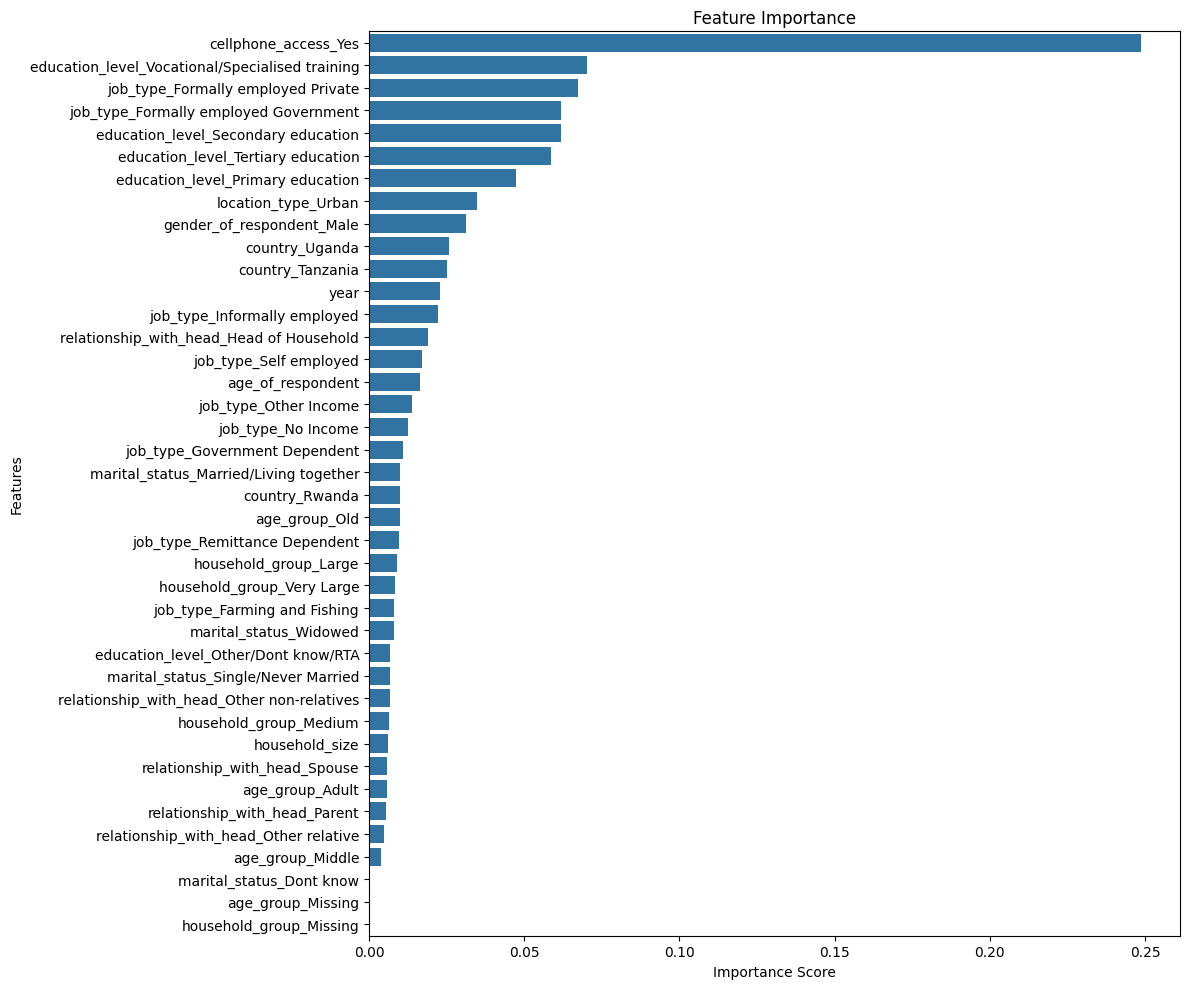

In [61]:
plt.figure(figsize=(12,10))

# Sort feature importances for better visualization
importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
sns.barplot(x=importance.values, y=importance.index)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

The XGBoost model learns patterns from education, job type, and age-related features. It handles non-linear relationships and class imbalance effectively.

## Model Evaluation

## Accuracy Score

In [62]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.7940488841657811


Accuracy gives a general performance view but is not enough for imbalanced data (like your dataset: 86% vs 14%).

Accuracy is used as a baseline metric only.

## Confusion Matrix

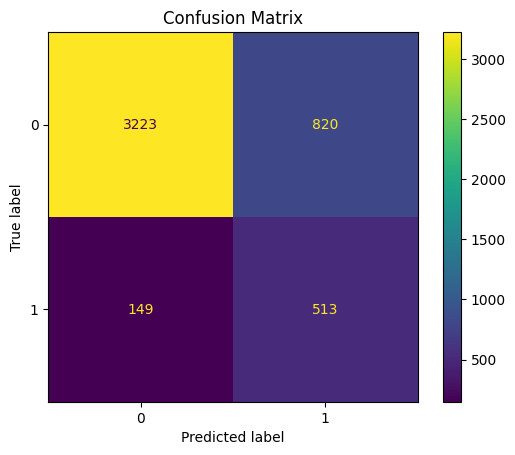

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_val, y_val)
plt.title("Confusion Matrix")
plt.show()

This helps detect if the model is biased toward the majority class (No).

Confusion matrix is used for detailed class-level evaluation.

## Create Submission File

In [64]:
# view the submission file
ss.head()

,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


In [65]:
# Get the predicted result for the test Data
test_predictions_encoded = model.predict(X_test)

# Convert predictions back to original labels if needed, using the LabelEncoder
test_predictions_labels = le.inverse_transform(test_predictions_encoded)

In [70]:
# Create submission DataFrame using the saved test_ids and predicted labels
submission = pd.DataFrame({
    "uniqueid": test_ids["uniqueid"] + " x " + test_ids["country"],
    "bank_account": test_predictions_labels
})

In [69]:
#show the five sample
submission.sample(5)

,uniqueid,bank_account
7609,uniqueid_7884 x Tanzania,0
5894,uniqueid_12029 x Rwanda,1
1007,uniqueid_7076 x Kenya,1
4689,uniqueid_10824 x Rwanda,0
7749,uniqueid_8024 x Tanzania,1


Save results in the CSV file.


In [74]:
# Create submission csv file csv file
from google.colab import files
submission.to_csv('first_submission.csv', index = False)
files.download('first_submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>